### **Práctica 7 - Pipeline para clasificación de textos - BoW y TF-IDF**
- Lectura y análisis preliminar del dataset.
- Preprocesamiento de textos.
- Procesamiento de la variables de salida.
- Representación vectorial del lenguaje.
    - BoW.
    - TF-IDF.
- Balance y partición del conjunto de datos.
- Entrenamiento y evaluación de modelos.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, accuracy_score

import nltk
import string
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

#### **Lectura del Dataset**

In [ ]:
# Lectura del dataset

# Vista de los datos
df.head()

#### **Preprocesamiento de Textos**

In [ ]:
def clean_text(text):
    text = text.lower()
    text = ''.join([char for char in text if char not in string.punctuation])
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words and len(word) > 3]
    return " ".join(tokens)

df['clean_text'] = df['text'].apply(clean_text)

In [ ]:
df['clean_text']

#### **Procesamiento de variable de salida**

In [ ]:
# Convertir sentimiento a números
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['airline_sentiment'])  # 0: negative, 1: neutral, 2: positive

In [ ]:
df['airline_sentiment'].value_counts()

In [ ]:
df['label'].value_counts()

In [ ]:
y = df['label']

#### **Representación del lenguaje con BoW (Bag of Words)**

In [ ]:
bow = CountVectorizer(max_features=5000)
X_bow = bow.fit_transform(df['clean_text']).toarray()

In [ ]:
X_bow.shape

In [ ]:
X_bow

#### **Representación del lenguaje con TF-IDF**

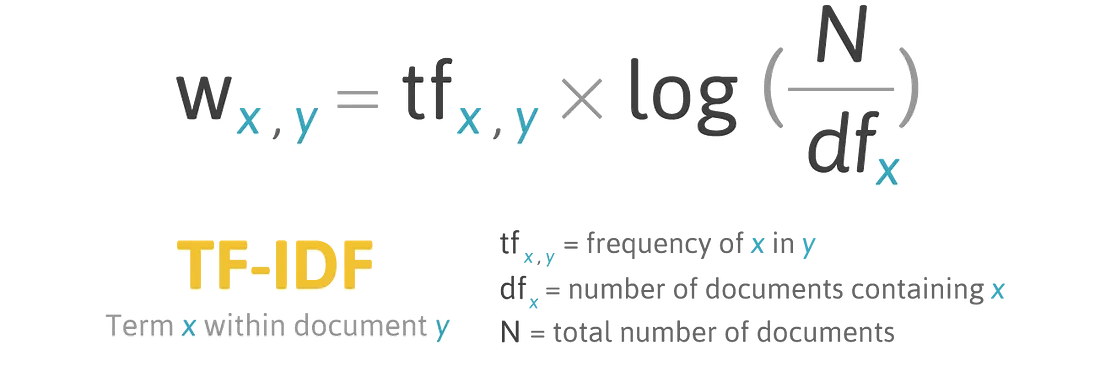

In [ ]:
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['clean_text']).toarray()

In [ ]:
X_tfidf.shape

In [ ]:
X_tfidf

#### **Balance del conjunto de datos**

In [ ]:
sns.countplot(data=df, y=y)

In [ ]:
# SMOTE para balancear ambos conjuntos de datos
smote = SMOTE()

# Para BoW
X_bow_res, y_bow_res = smote.fit_resample(X_bow, y)

# Para TF-IDF
X_tfidf_res, y_tfidf_res = smote.fit_resample(X_tfidf, y)

In [ ]:
sns.countplot(y=y_bow_res)

#### **División dataset en train/test**

In [ ]:
X_bow_train, X_bow_test, y_bow_train, y_bow_test = train_test_split(X_bow_res, y_bow_res, test_size=0.2, random_state=42)
X_tfidf_train, X_tfidf_test, y_tfidf_train, y_tfidf_test = train_test_split(X_tfidf_res, y_tfidf_res, test_size=0.2, random_state=42)

#### **Definir modelos de AA**

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Naive Bayes": MultinomialNB()
}

#### **Entrenar y evaluar modelos**


In [ ]:
# Guardar los resultados
resultados_accuracy = []

def evaluate_models(X_train, X_test, y_train, y_test, vectorizer_name):
    print(f"\n Resultados con {vectorizer_name}:\n" + "-"*40)
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        print(f"\n Modelo: {name}")
        print("Accuracy:", acc)
        print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

         # Guardar en la lista global
        resultados_accuracy.append({
            'Modelo': name,
            'Vectorización': vectorizer_name,
            'Accuracy': acc
        })

In [ ]:
# Evaluación con BoW
evaluate_models(X_bow_train, X_bow_test, y_bow_train, y_bow_test, "Bag of Words")

# Evaluación con TF-IDF
evaluate_models(X_tfidf_train, X_tfidf_test, y_tfidf_train, y_tfidf_test, "TF-IDF")

#### **Resultados**

In [ ]:
df_results = pd.DataFrame(resultados_accuracy)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_results, x='Modelo', y='Accuracy', hue='Vectorización', palette='Set2')
plt.title('Comparación de Accuracy por Modelo y Vectorización')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()